Libaries
=========

In [10]:
# Start by importing some libraries that may be useful
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

# Data

In [11]:
# START TWEAKING DATA SIZE HERE
SEED = 100
np.random.seed(SEED)
torch.manual_seed(SEED)
nrows = 5124
DAYS_TO_PREDICT = 90
FEATURES = ["X1", "X2", "X3"]
TARGET = "y"
COLUMNS = FEATURES + [TARGET]
DAYS_TO_LOOKBACK = 1

In [12]:
# create a date range
dates = pd.date_range(start="1999-11-17", periods=nrows, freq="D")

# create a random dataframe
data = pd.DataFrame(np.random.randn(nrows, len(COLUMNS)), index=dates, columns=COLUMNS)

# create TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=5, test_size=DAYS_TO_PREDICT, gap=DAYS_TO_LOOKBACK)

In [13]:
# Check
data.tail(5)

,X1,X2,X3,y
2013-11-22,0.236632,1.915702,0.544633,-0.110481
2013-11-23,0.478005,-0.203294,-0.165001,0.631766
2013-11-24,-1.369339,2.188914,-0.467300,-0.243952
2013-11-25,-0.533710,0.660889,-0.392533,0.958331
2013-11-26,0.013168,-0.270417,0.229628,-1.227275


LSTM Class Definition
=====================

In [14]:
class MyLSTM(nn.Module):
    def __init__(self, base_params=None):
        super(MyLSTM, self).__init__()

        # Default hyperparameters
        defaults = {
            "input_dimension": len(FEATURES),
            "hidden_dimension": 8,
            "layer_dimension": 1,
            "output_dimension": 1,
            "dropout": 0.1,
            "lr": 1e-3,
            "num_epochs": 10,
            "gap": DAYS_TO_LOOKBACK,
        }
        
        # Merge user-supplied params with defaults
        if base_params is not None:
            defaults.update(base_params)
        self.params = defaults

        # Extract for convenience
        input_dim  = self.params["input_dimension"]
        hidden_dim = self.params["hidden_dimension"]
        num_layers = self.params["layer_dimension"]
        output_dim = self.params["output_dimension"]
        dropout    = self.params["dropout"]

        # --- Define LSTM layers ---
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, h0=None, c0=None):
        """
        x: (B, L, F)
        """
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.params["layer_dimension"], x.size(0), self.params["hidden_dimension"])
            c0 = torch.zeros(self.params["layer_dimension"], x.size(0), self.params["hidden_dimension"])

        out, _ = self.lstm(x, (h0, c0))     # out: (B, L, H)
        out = self.fc(out[:, -1, :])        # use last timestep
        return out.squeeze(-1)

Model Creation
==============

In [15]:
# Create model
model = MyLSTM()
model

MyLSTM(
  (lstm): LSTM(3, 8, batch_first=True)
  (fc): Linear(in_features=8, out_features=1, bias=True)
)

Train Model
===========

In [16]:
def train_lstm(base_params=None, tss=None, data=None):
    import gc
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn as nn
    from sklearn.metrics import mean_squared_error

    preds, tests, scores = [], [], []
    last_model = None

    for fold, (train_idx, test_idx) in enumerate(tss.split(data), 1):
        # --- Initialize model ---
        model = MyLSTM(base_params)
        learning_rate = (base_params or {}).get("lr", 0.001)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        L = int(model.params["gap"])
        epochs = int(model.params["num_epochs"])

        # --- Prepare data ---
        train_df = data.iloc[train_idx]
        test_df  = data.iloc[test_idx]

        X_train = train_df[FEATURES].to_numpy(dtype=np.float32)
        y_train = train_df[TARGET].to_numpy(dtype=np.float32)
        X_test  = test_df[FEATURES].to_numpy(dtype=np.float32)
        y_test  = test_df[TARGET].to_numpy(dtype=np.float32)   

        # --- Training ---
        print(f"\n[Fold {fold}] Training...")
        model.train()
        for epoch in range(epochs):
            total_loss = 0.0
            for i in range(len(X_train) - L):
                # single sequence window and target
                x_seq = torch.as_tensor(X_train[i:i+L], dtype=torch.float32).unsqueeze(0)  # [1, L, D]
                y_t   = torch.as_tensor([y_train[i+L]], dtype=torch.float32)               # [1]

                optimizer.zero_grad(set_to_none=True)
                y_pred = model(x_seq).view(-1)  # flatten to [1]
                y_t = y_t.view(-1)              # flatten to [1]

                loss = criterion(y_pred, y_t)   
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += float(loss.detach())

            if (epoch + 1) % 5 == 0:
                avg = total_loss / max(len(X_train) - L, 1)     
                print(f"Epoch {epoch+1:3d} | Training MSE: {avg:.4f}")

        # --- Testing ---
        model.eval()
        preds_fold = []
        with torch.no_grad():
            for i in range(len(X_test) - L):
                x_seq = torch.as_tensor(X_test[i:i+L], dtype=torch.float32).unsqueeze(0)
                y_hat = model(x_seq).view(-1)[0].item()  # scalar prediction
                preds_fold.append(y_hat)

        # Align predictions and compute MSE
        idx = test_df.index[L:]
        y_test_seq = y_test[L:]
        y_pred_seq = np.array(preds_fold, dtype=np.float32)[:len(y_test_seq)]

        y_test_series = pd.Series(y_test_seq, index=idx)
        y_pred_series = pd.Series(y_pred_seq, index=idx)

        mse = mean_squared_error(y_test_series, y_pred_series)
        print(f"[Fold {fold}] Testing MSE = {mse:.4f}")

        preds.append(y_pred_series)
        tests.append(y_test_series)
        scores.append(mse)
        last_model = model
        gc.collect()

    return last_model, preds, tests, scores

Model Predictions
=================

In [17]:
reg, preds, tests, scores = train_lstm(tss=tss, data=data)
print(f"Average Errors: {np.mean(scores):.4f}")


[Fold 1] Training...
Epoch   5 | Training MSE: 1.0186
Epoch  10 | Training MSE: 1.0182
[Fold 1] Testing MSE = 0.9932

[Fold 2] Training...
Epoch   5 | Training MSE: 1.0196
Epoch  10 | Training MSE: 1.0188
[Fold 2] Testing MSE = 1.0158

[Fold 3] Training...
Epoch   5 | Training MSE: 1.0194
Epoch  10 | Training MSE: 1.0186
[Fold 3] Testing MSE = 1.1057

[Fold 4] Training...
Epoch   5 | Training MSE: 1.0202
Epoch  10 | Training MSE: 1.0198
[Fold 4] Testing MSE = 1.0027

[Fold 5] Training...
Epoch   5 | Training MSE: 1.0208
Epoch  10 | Training MSE: 1.0200
[Fold 5] Testing MSE = 0.8162
Average Errors: 0.9867


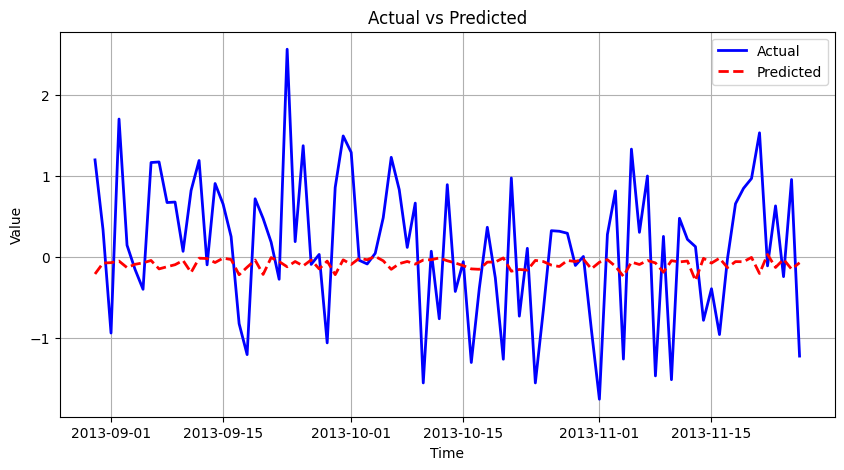

In [18]:
# Plot the actual results vs. model prediction for the most recent period
plt.figure(figsize=(10,5))
plt.plot(tests[-1], label='Actual', color='blue', linewidth=2)
plt.plot(preds[-1], label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()